# Connect Forest Management Model with Forest Carbon Budget Model (without calibration)

## Set up Modelling Environment

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons',  'bau_redchrs', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'bau_gldbr', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'bau_eqtslvr', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons','evenflow_cons',  'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='equitysilver',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['equitysilver'],  # Set initial options based on default case study
    value=scenario_options['equitysilver'][2],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='max_hv',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=2, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=2, options=('no_cons', 'evenflow_cons', 'bau_eqtslvr', 'eqtslvr_AAC_90…

Dropdown(description='Objective:', options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='max_hv')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

# Retrieve model details based on case study
model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

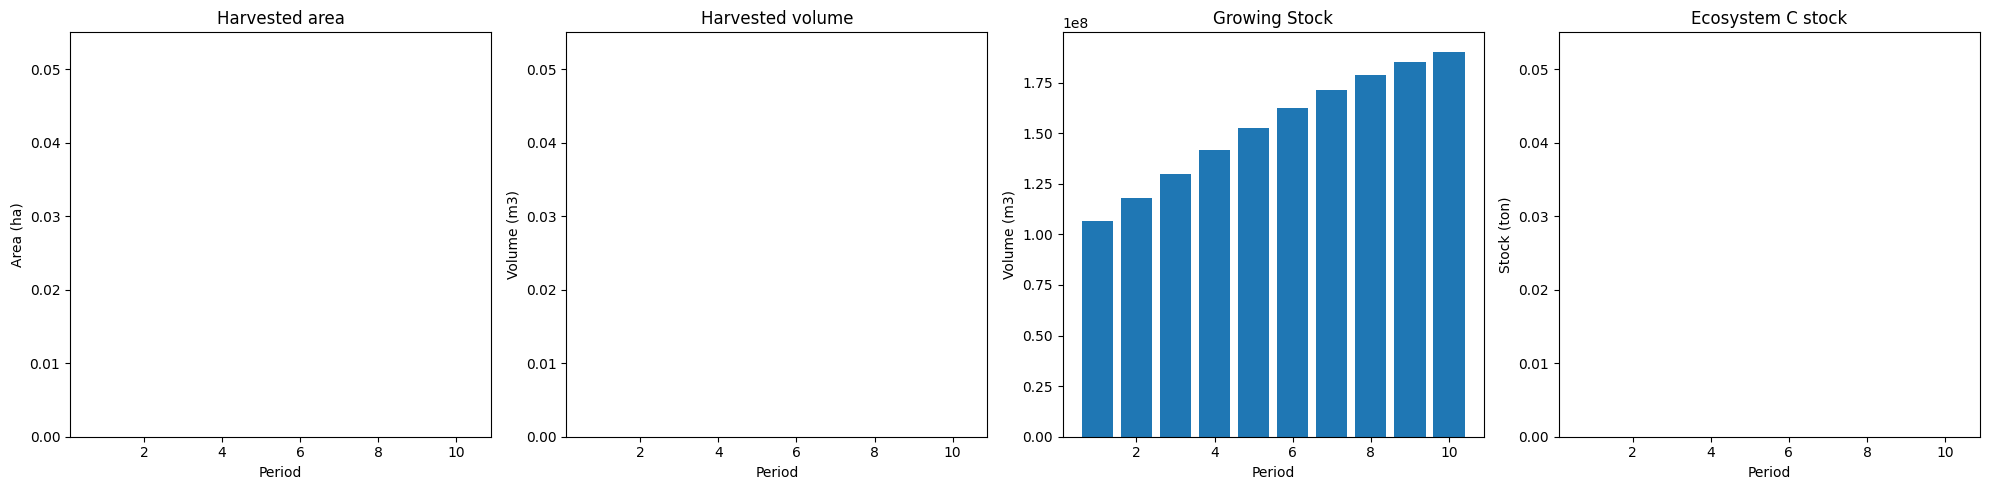

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_scheduling_maxstock.pdf


(<Figure size 2000x500 with 4 Axes>,
 array([<Axes: title={'center': 'Harvested area'}, xlabel='Period', ylabel='Area (ha)'>,
        <Axes: title={'center': 'Harvested volume'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Growing Stock'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Ecosystem C stock'}, xlabel='Period', ylabel='Stock (ton)'>],
       dtype=object))

In [10]:
# Check the Forest Inventory of the Forest Model
df = compile_scenario_maxstock(fm, case_study, obj_mode, scenario_name)
plot_scenario_maxstock(df, case_study, obj_mode, scenario_name)

## Hard-link `ForestModel` to `libcbm`

Prepare CBM input files

In [11]:
# Define Disturance Types
disturbance_type_mapping = [{'user_dist_type': 'harvest', 'default_dist_type': 'Clearcut harvesting without salvage'},
                            {'user_dist_type': 'fire', 'default_dist_type': 'Wildfire'}]
for dtype_key in fm.dtypes:
    fm.dt(dtype_key).last_pass_disturbance = 'fire' if dtype_key[2] == dtype_key[4] else 'harvest'

In [12]:
sit_config, sit_tables = fm.to_cbm_sit(softwood_volume_yname='swdvol', 
                                       hardwood_volume_yname='hwdvol', 
                                       admin_boundary='British Columbia', 
                                       eco_boundary='Montane Cordillera',
                                       disturbance_type_mapping=disturbance_type_mapping)

Here are other two ways to generate sit tables. But they are only suitbale for small forest model since they take too much running time and memory

In [13]:
# Define Time Steps
n_steps = fm.horizon * fm.period_length

# Run CBM and Generate CBM 0utputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

Emissions from all biomass components only resulting from fire disturbance, while these from all DOM pools resulting from annual decay processes and fire disturbance.

In [14]:
# Define Carbon Pools
biomass_pools = ['SoftwoodMerch','SoftwoodFoliage', 'SoftwoodOther', 'SoftwoodCoarseRoots','SoftwoodFineRoots',                        
                 'HardwoodMerch', 'HardwoodFoliage', 'HardwoodOther', 'HardwoodCoarseRoots', 'HardwoodFineRoots']
dom_pools = ['AboveGroundVeryFastSoil', 'BelowGroundVeryFastSoil', 'AboveGroundFastSoil', 'BelowGroundFastSoil',
             'MediumSoil', 'AboveGroundSlowSoil', 'BelowGroundSlowSoil', 'SoftwoodStemSnag', 'SoftwoodBranchSnag',
             'HardwoodStemSnag', 'HardwoodBranchSnag']
emissions_pools = ['CO2', 'CH4', 'CO', 'NO2']
products_pools = ['Products']
ecosystem_pools = biomass_pools + dom_pools
all_pools = biomass_pools + dom_pools + emissions_pools + products_pools

In [15]:
# Define Carbon Fluxes
annual_process_fluxes = [
    'DecayDOMCO2Emission',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir'
]


npp_fluxes=[
    'DeltaBiomass_AG', 
    'DeltaBiomass_BG'
]

# decay_emissions_fluxes = [
#     'DecayVFastAGToAir',
#     'DecayVFastBGToAir',
#     'DecayFastAGToAir',
#     'DecayFastBGToAir',
#     'DecayMediumToAir',
#     'DecaySlowAGToAir',
#     'DecaySlowBGToAir',
#     'DecaySWStemSnagToAir',
#     'DecaySWBranchSnagToAir',
#     'DecayHWStemSnagToAir',
#     'DecayHWBranchSnagToAir'
# ]
ecosystem_decay_emissions_pools = [
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']

disturbance_production_fluxes = [
    'DisturbanceSoftProduction',
    'DisturbanceHardProduction',
    'DisturbanceDOMProduction'   
]

disturbance_emissions_fluxes = [
    'DisturbanceMerchToAir',
    'DisturbanceFolToAir',
    'DisturbanceOthToAir',
    'DisturbanceCoarseToAir',
    'DisturbanceFineToAir',
    'DisturbanceVFastAGToAir',
    'DisturbanceVFastBGToAir',
    'DisturbanceFastAGToAir',
    'DisturbanceFastBGToAir',
    'DisturbanceMediumToAir',
    'DisturbanceSlowAGToAir',
    'DisturbanceSlowBGToAir',
    'DisturbanceSWStemSnagToAir',
    'DisturbanceSWBranchSnagToAir',
    'DisturbanceHWStemSnagToAir',
    'DisturbanceHWBranchSnagToAir'   
]

all_fluxes = [
    'DisturbanceCO2Production',
    'DisturbanceCH4Production',
    'DisturbanceCOProduction',
    'DisturbanceBioCO2Emission',
    'DisturbanceBioCH4Emission',
    'DisturbanceBioCOEmission',
    'DecayDOMCO2Emission',
    'DisturbanceSoftProduction',
    'DisturbanceHardProduction',
    'DisturbanceDOMProduction',
    'DeltaBiomass_AG',
    'DeltaBiomass_BG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput',
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir',
    'DisturbanceMerchToAir',
    'DisturbanceFolToAir',
    'DisturbanceOthToAir',
    'DisturbanceCoarseToAir',
    'DisturbanceFineToAir',
    'DisturbanceDOMCO2Emission',
    'DisturbanceDOMCH4Emission',
    'DisturbanceDOMCOEmission',
    'DisturbanceMerchLitterInput',
    'DisturbanceFolLitterInput',
    'DisturbanceOthLitterInput',
    'DisturbanceCoarseLitterInput',
    'DisturbanceFineLitterInput',
    'DisturbanceVFastAGToAir',
    'DisturbanceVFastBGToAir',
    'DisturbanceFastAGToAir',
    'DisturbanceFastBGToAir',
    'DisturbanceMediumToAir',
    'DisturbanceSlowAGToAir',
    'DisturbanceSlowBGToAir',
    'DisturbanceSWStemSnagToAir',
    'DisturbanceSWBranchSnagToAir',
    'DisturbanceHWStemSnagToAir',
    'DisturbanceHWBranchSnagToAir'
]
grossgrowth_ag = [
    "DeltaBiomass_AG",
    "TurnoverMerchLitterInput",
    "TurnoverFolLitterInput",
    "TurnoverOthLitterInput",
]

grossgrowth_bg = [
    "DeltaBiomass_BG",
    "TurnoverCoarseLitterInput",
    "TurnoverFineLitterInput",
]

product_flux = [
     "DisturbanceSoftProduction",
     "DisturbanceHardProduction",
     "DisturbanceDOMProduction",
]

ecosystem_decay_emissions_pools = [
    'DecayVFastAGToAir',
    'DecayVFastBGToAir',
    'DecayFastAGToAir',
    'DecayFastBGToAir',
    'DecayMediumToAir',
    'DecaySlowAGToAir',
    'DecaySlowBGToAir',
    'DecaySWStemSnagToAir',
    'DecaySWBranchSnagToAir',
    'DecayHWStemSnagToAir',
    'DecayHWBranchSnagToAir']
GrossGrowth_pools = [
    'DeltaBiomass_AG',
    'TurnoverMerchLitterInput',
    'TurnoverFolLitterInput',
    'TurnoverOthLitterInput',
    'DeltaBiomass_BG',
    'TurnoverCoarseLitterInput',
    'TurnoverFineLitterInput']

In [16]:
# Define Sum Carbon Pools and Sum Carbon Fluxes
pools = ecosystem_pools
# fluxes = decay_emissions_fluxes + disturbance_emissions_fluxes
# gross_growth = grossgrowth_ag + grossgrowth_bg
fluxes = ecosystem_decay_emissions_pools
gross_growth = GrossGrowth_pools
sum_pools = ['ecosystem', 'biomass', 'DOM']

,Biomass,DOM,Ecosystem,All_Emissions,Gross_Growth,Stock_Change
Year,,,,,,
0,5.822073e+07,1.222542e+08,1.804750e+08,0.000000e+00,0.000000e+00,0.000000
1,5.871998e+07,1.221095e+08,1.808295e+08,2.698916e+06,3.053426e+06,-354510.028018
2,5.921411e+07,1.219807e+08,1.811948e+08,2.699385e+06,3.064685e+06,-365300.196877
3,5.970696e+07,1.218664e+08,1.815734e+08,2.700477e+06,3.079076e+06,-378598.301206
4,6.020047e+07,1.217660e+08,1.819664e+08,2.702128e+06,3.095212e+06,-393083.488615
...,...,...,...,...,...,...
96,8.888489e+07,1.328625e+08,2.217474e+08,3.118794e+06,3.422864e+06,-304069.939522
97,8.900069e+07,1.330478e+08,2.220485e+08,3.121645e+06,3.422719e+06,-301073.773681
98,8.910958e+07,1.332344e+08,2.223440e+08,3.124494e+06,3.420029e+06,-295534.434088


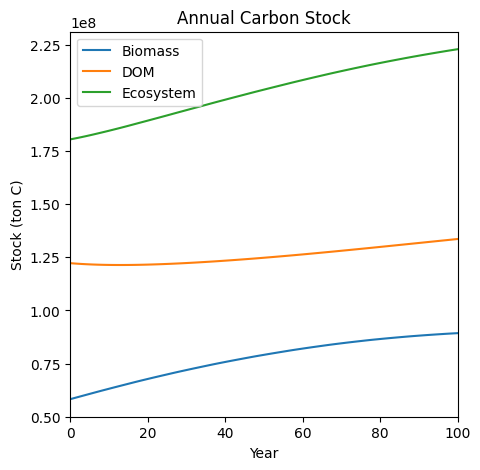

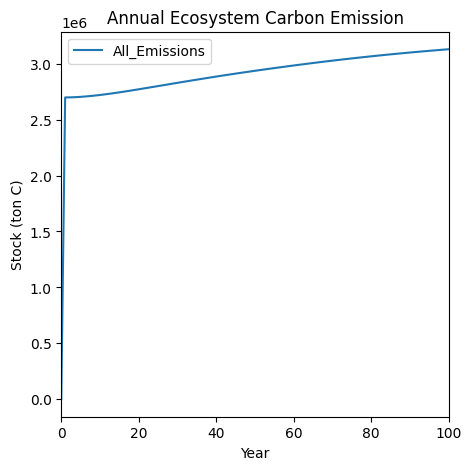

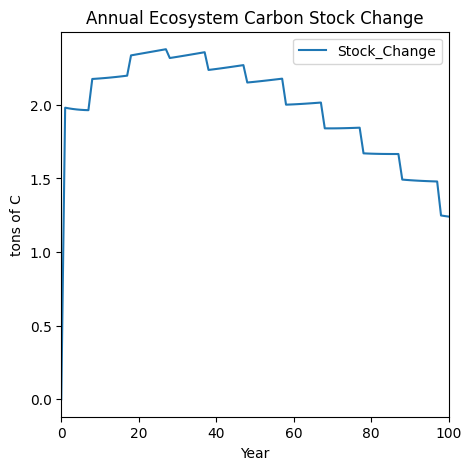

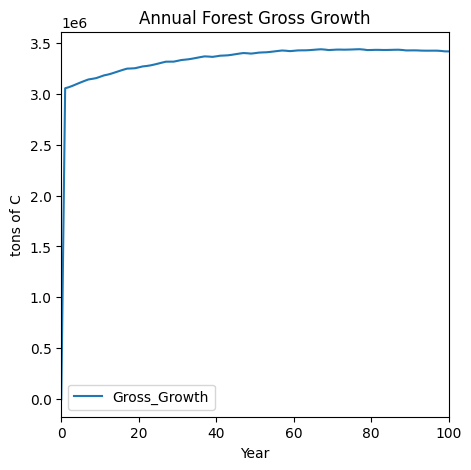

In [17]:
# Report Annual CBM Results
cbm_report(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)

## Plug-in Carbon Yield Curves

In [18]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/equitysilver_c_curves_p.pkl
Loaded data from ./inputs/curves/equitysilver_c_curves_f.pkl


In [19]:
# In order to reduce the impact of DOM input
# c_curves_p.loc[:59, 'DOM'] = c_curves_p.loc[:59, 'DOM'] * 0.1
# c_curves_p['ecosystem'] = c_curves_p['DOM'] + c_curves_p['biomass']

In [20]:
# Plug carbon yield curves into forest model
# plugin_c_curves(fm, c_curves_p, pools=sum_pools) #Plugs in only c_curves_p
plugin_c_curves_both(fm, c_curves_p, c_curves_f)

In [21]:
bootstrap_ogi(fm)

In [22]:
# Check if all carbon yield curves are plugged in well.
fm.yields

[(('?', '?', '?', '?', '?', '?'), '', []),
 (('?', '?', '?', '?', '12', '12'),
  'a',
  [('s1201', <ws3.core.Curve at 0x7f6589b33e50>),
   ('ecosystem', <ws3.core.Curve at 0x7f65690f4970>),
   ('biomass', <ws3.core.Curve at 0x7f65690f6860>),
   ('DOM', <ws3.core.Curve at 0x7f65690f45e0>),
   ('net_emissions', <ws3.core.Curve at 0x7f65690f49a0>),
   ('total_emissions', <ws3.core.Curve at 0x7f65690f5ea0>),
   ('gross_growth', <ws3.core.Curve at 0x7f65690f55d0>),
   ('ecosystem', <ws3.core.Curve at 0x7f65690f4970>),
   ('biomass', <ws3.core.Curve at 0x7f65690f6860>),
   ('DOM', <ws3.core.Curve at 0x7f65690f45e0>),
   ('net_emissions', <ws3.core.Curve at 0x7f65690f49a0>),
   ('total_emissions', <ws3.core.Curve at 0x7f65690f5ea0>),
   ('gross_growth', <ws3.core.Curve at 0x7f65690f55d0>),
   ('ecosystem', <ws3.core.Curve at 0x7f65690f4970>),
   ('biomass', <ws3.core.Curve at 0x7f65690f6860>),
   ('DOM', <ws3.core.Curve at 0x7f65690f45e0>),
   ('net_emissions', <ws3.core.Curve at 0x7f65690f49

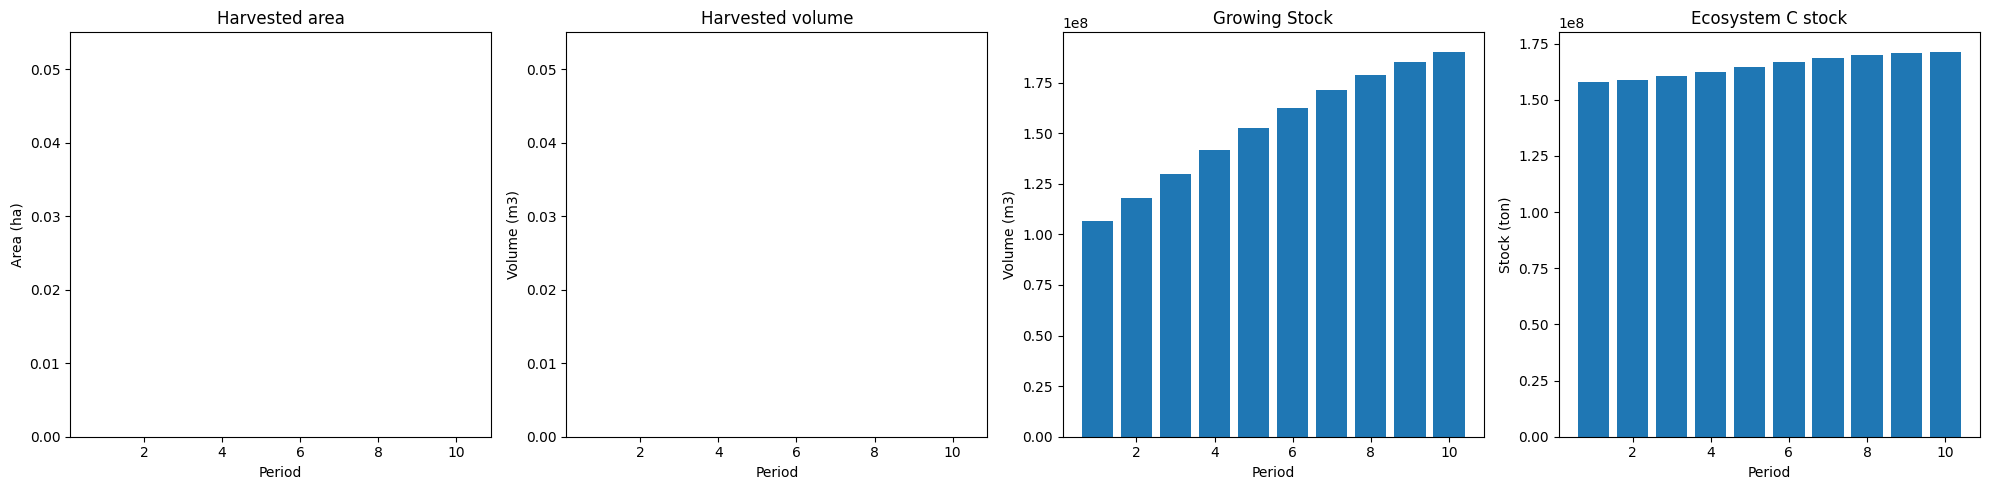

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_scheduling_maxstock.pdf


(<Figure size 2000x500 with 4 Axes>,
 array([<Axes: title={'center': 'Harvested area'}, xlabel='Period', ylabel='Area (ha)'>,
        <Axes: title={'center': 'Harvested volume'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Growing Stock'}, xlabel='Period', ylabel='Volume (m3)'>,
        <Axes: title={'center': 'Ecosystem C stock'}, xlabel='Period', ylabel='Stock (ton)'>],
       dtype=object))

In [23]:
# Check the Forest Inventory of the ws3 Model without harvesting
df = compile_scenario_maxstock(fm, case_study, obj_mode, scenario_name)
plot_scenario_maxstock(df, case_study, obj_mode, scenario_name)

In [24]:
#Define Basic Variables
softwood_volume_yname='swdvol' 
hardwood_volume_yname='hwdvol'
n_yield_vals=100

In [25]:
#Generate New Sit_events file
sit_events = compile_events(fm, softwood_volume_yname, hardwood_volume_yname, n_yield_vals)

In [26]:
# Replace the Sit_events file in the sit tables
sit_tables['sit_events'] = sit_events

In [27]:
sit_events

,theme0,theme1,theme2,theme3,theme4,theme5,species,using_age_class,min_softwood_age,max_softwood_age,...,MinSWMerchStemSnagC,MaxSWMerchStemSnagC,MinHWMerchStemSnagC,MaxHWMerchStemSnagC,efficiency,sort_type,target_type,target,disturbance_type,disturbance_year


In [28]:
# Run CBM and Generate CBM Ouputs
cbm_output = run_cbm_emissionstock(sit_config, sit_tables, n_steps)

,Biomass,DOM,Ecosystem,All_Emissions,Gross_Growth,Stock_Change,Net_Emissions
Year,,,,,,,
0,5.822073e+07,1.222542e+08,1.804750e+08,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
1,5.871998e+07,1.221095e+08,1.808295e+08,9.896026e+06,-1.119590e+07,-354510.028018,-1.299870e+06
2,5.921411e+07,1.219807e+08,1.811948e+08,9.897744e+06,-1.123718e+07,-365300.196877,-1.339434e+06
3,5.970696e+07,1.218664e+08,1.815734e+08,9.901750e+06,-1.128994e+07,-378598.301206,-1.388194e+06
4,6.020047e+07,1.217660e+08,1.819664e+08,9.907804e+06,-1.134911e+07,-393083.488615,-1.441306e+06
...,...,...,...,...,...,...,...
96,8.888489e+07,1.328625e+08,2.217474e+08,1.143558e+07,-1.255050e+07,-304069.939522,-1.114923e+06
97,8.900069e+07,1.330478e+08,2.220485e+08,1.144603e+07,-1.254997e+07,-301073.773681,-1.103937e+06
98,8.910958e+07,1.332344e+08,2.223440e+08,1.145648e+07,-1.254011e+07,-295534.434088,-1.083626e+06


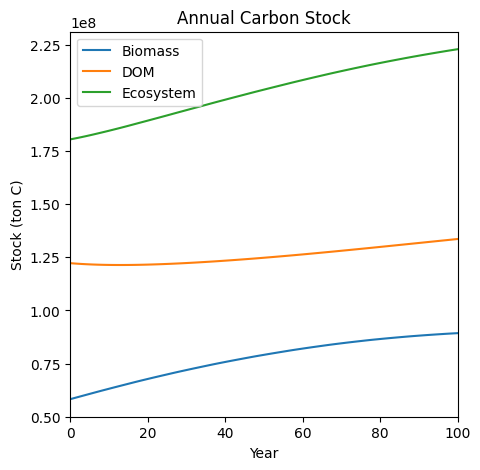

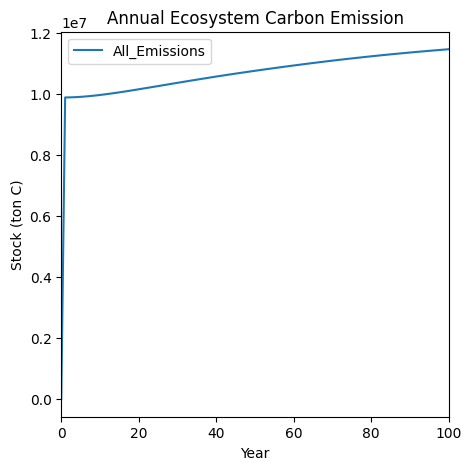

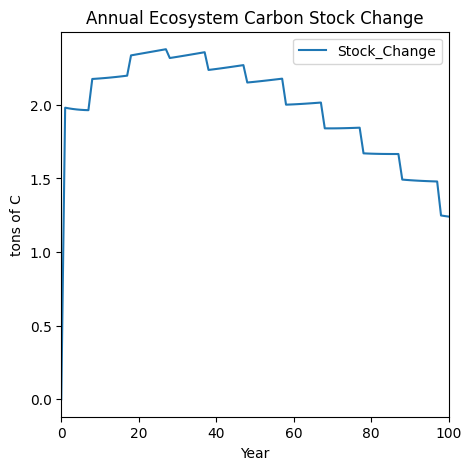

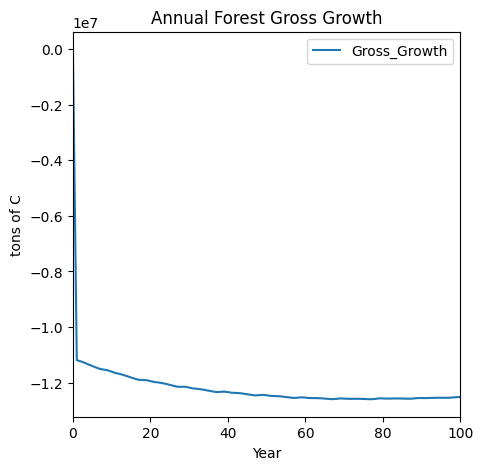

In [29]:
# Report Annual CBM Outputs
# cbm_report(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)
cbm_report_both(fm, cbm_output, biomass_pools, dom_pools, fluxes, gross_growth)

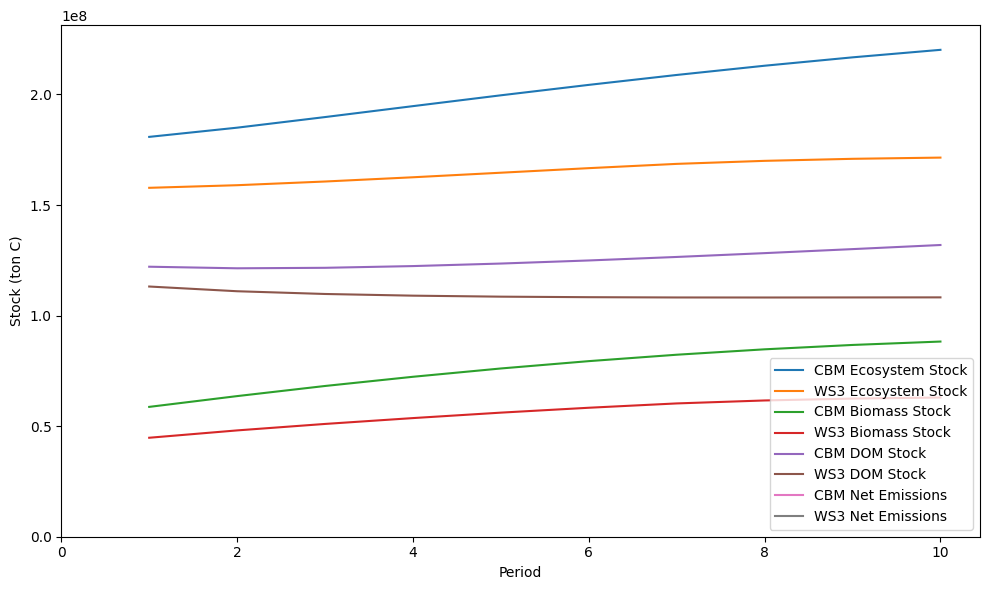

(   period  biomass_stock     dom_stock     eco_stock  \
 0       1   5.871998e+07  1.221095e+08  1.808295e+08   
 1       2   6.359534e+07  1.213954e+08  1.849907e+08   
 2       3   6.817118e+07  1.216164e+08  1.897876e+08   
 3       4   7.233254e+07  1.223969e+08  1.947294e+08   
 4       5   7.608993e+07  1.235419e+08  1.996318e+08   
 5       6   7.940788e+07  1.249374e+08  2.043453e+08   
 6       7   8.230760e+07  1.265239e+08  2.088315e+08   
 7       8   8.475152e+07  1.282544e+08  2.130059e+08   
 8       9   8.672844e+07  1.300697e+08  2.167982e+08   
 9      10   8.826551e+07  1.319300e+08  2.201955e+08   
 
    ecosystem_decay_emissions  gross_growth  net_emissions  eco_stock_change  
 0               9.896026e+06 -1.119590e+07  -1.299870e+06      0.000000e+00  
 1               9.992804e+06 -1.165899e+07  -1.666185e+06      4.161254e+06  
 2               1.018479e+07 -1.198239e+07  -1.797605e+06      4.796894e+06  
 3               1.039640e+07 -1.221306e+07  -1.816661e

In [30]:
# Compare the carbon outputs from ws3 (table above) and libcbm (table below)
# compare_ws3_cbm(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, plots='whole')
compare_ws3_cbm_both(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, ecosystem_decay_emissions_pools, GrossGrowth_pools, plots="whole")

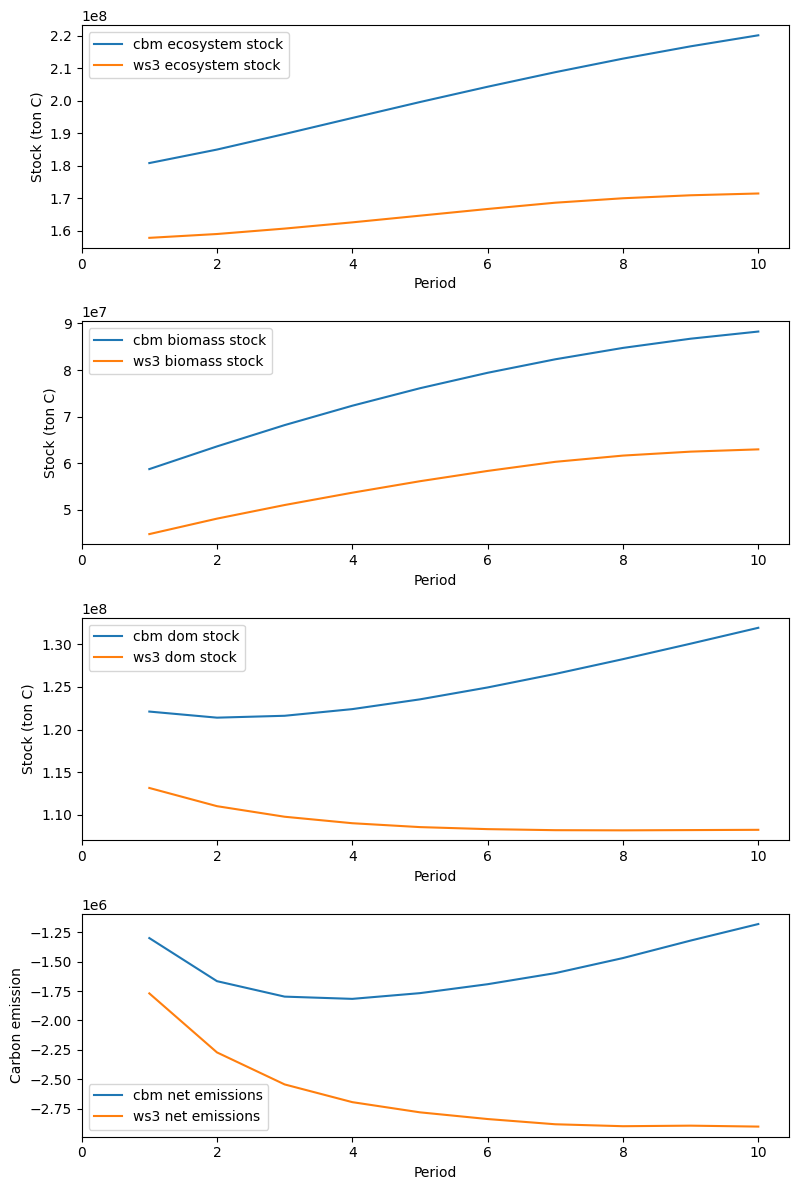

(   period  biomass_stock     dom_stock     eco_stock  \
 0       1   5.871998e+07  1.221095e+08  1.808295e+08   
 1       2   6.359534e+07  1.213954e+08  1.849907e+08   
 2       3   6.817118e+07  1.216164e+08  1.897876e+08   
 3       4   7.233254e+07  1.223969e+08  1.947294e+08   
 4       5   7.608993e+07  1.235419e+08  1.996318e+08   
 5       6   7.940788e+07  1.249374e+08  2.043453e+08   
 6       7   8.230760e+07  1.265239e+08  2.088315e+08   
 7       8   8.475152e+07  1.282544e+08  2.130059e+08   
 8       9   8.672844e+07  1.300697e+08  2.167982e+08   
 9      10   8.826551e+07  1.319300e+08  2.201955e+08   
 
    ecosystem_decay_emissions  gross_growth  net_emissions  eco_stock_change  
 0               9.896026e+06 -1.119590e+07  -1.299870e+06      0.000000e+00  
 1               9.992804e+06 -1.165899e+07  -1.666185e+06      4.161254e+06  
 2               1.018479e+07 -1.198239e+07  -1.797605e+06      4.796894e+06  
 3               1.039640e+07 -1.221306e+07  -1.816661e

In [31]:
# Compare the carbon outputs from ws3 (table above) and libcbm (table below)
# compare_ws3_cbm(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, plots='individual')
compare_ws3_cbm_both(fm, cbm_output, disturbance_type_mapping, biomass_pools, dom_pools, ecosystem_decay_emissions_pools, GrossGrowth_pools, plots="individual")

running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x8fbcd670
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [1e-01, 6e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8907 columns
Presolve time: 0.33s
Presolved: 8375 rows, 74351 columns, 536194 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 2.583e+05
 Factor NZ  : 3.385e+05 (roughly 36 MB of memory)
 Factor Ops

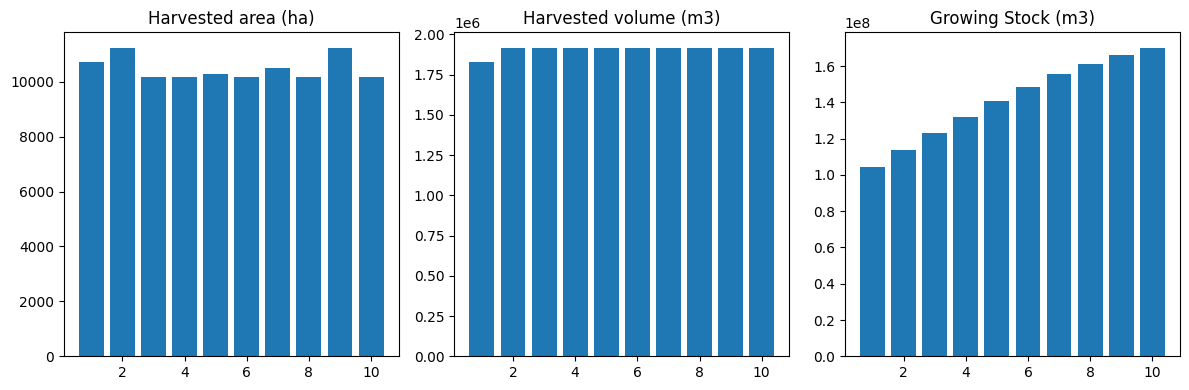

Plot saved to ./outputs/fig/equitysilver/equitysilver_max_hv_bau_eqtslvr_scheduling.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  20168
The economic indicator (the provincial government revenues) is:  687786
------------------------------------------------


[(('tsa03', '1', '1', '100', '1', '1'),
  102,
  23.316842856738205,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  109,
  25.116065567173226,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  112,
  29.56589760851907,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  114,
  3.6710466973094933,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  119,
  22.120505127584163,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  142,
  39.33410794274218,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  148,
  15.138808053686448,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '1', '100', '1', '1'),
  177,
  2.7728895415745916,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '7', '304', '7', '7'),
  139,
  22.609422445465864,
  'harvest',
  1,
  '_existing'),
 (('tsa03', '1', '7', '304', '7', '7'),
  189,
  0.520125642140486,
  'harv

In [43]:
run_scenario(fm, clt_percentage, hwp_pool_effect_value, displacement_effect, release_immediately_value, case_study, obj_mode, 'bau_eqtslvr', solver='gurobi')

In [33]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 18.2 minutes to run this script.
